In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [12]:
data = pd.read_csv('final_cleaned_data.csv', sep=';')
data = {
    'Feature_X': np.random.rand(100) * 10,
    'Feature_Y': np.random.rand(100) * 10 + np.random.randint(0, 3, 100) * 5,
    'Other_Feature_1': np.random.rand(100),
    'Other_Feature_2': np.random.rand(100)
}
df = pd.DataFrame(data)

In [13]:
df.head()

,Feature_X,Feature_Y,Other_Feature_1,Other_Feature_2
0,6.420787,0.513359,0.174287,0.447611
1,3.851049,15.802923,0.565915,0.943691
2,0.579064,12.961388,0.741275,0.514587
3,8.110879,11.904680,0.041660,0.147669
4,8.950624,10.695901,0.372373,0.630863


In [14]:
X = df[['Feature_X', 'Feature_Y']].values 

# --- 2. Scaling (Good practice for distance-based algorithms like K-Means) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
n_clusters = 3 # Choose your desired number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [16]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Feature_X', ylabel='Feature_Y'>

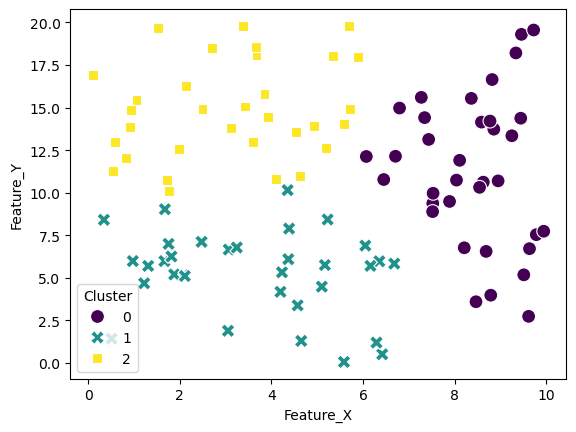

In [17]:
# Use seaborn scatterplot to easily color by cluster label
sns.scatterplot(
    x='Feature_X',
    y='Feature_Y',
    hue='Cluster', # Color points based on the 'Cluster' column
    palette='viridis', # Choose a color palette
    data=df,
    s=100, # Point size
    style='Cluster', # Use different markers for each cluster
    legend='full'
)

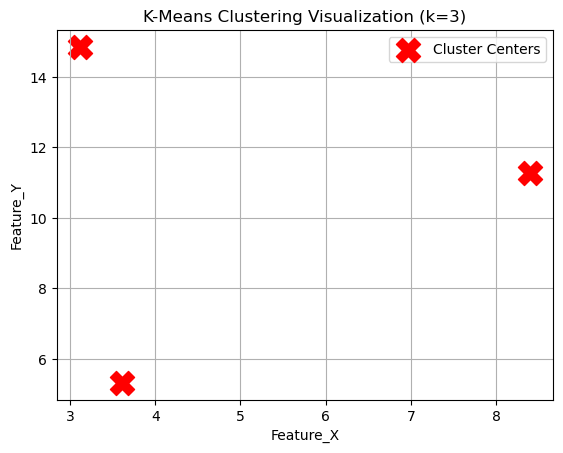

In [18]:
# Plot the cluster centers in a distinctive style
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], 
    centers[:, 1], 
    marker='X', 
    s=300, # Center size
    color='red', 
    label='Cluster Centers'
)

plt.title(f'K-Means Clustering Visualization (k={n_clusters})')
plt.xlabel('Feature_X')
plt.ylabel('Feature_Y')
plt.legend()
plt.grid(True)
plt.show()